# Atera reader — exploratory analysis (R / Seurat)

Loads a sample Atera output bundle with `LoadAtera()`,
runs a BPCells-backed sketch analysis (normalization, PCA, UMAP, clustering) that scales
to whole-transcriptome, millions-of-cell bundles, and visualizes results spatially.

To enable such scale we use:

- **BPCells + sketching**, not a full in-memory/full-resolution pipeline: `FindClusters`
  and `RunPCA` on the full cell count are either infeasible or take tens of minutes (see
  the "Normalization, PCA, UMAP, clustering" section below for why). Seurat5's sketch
  workflow (`SketchData`/`ProjectData`) runs the expensive steps on a small,
  statistically-representative subset of cells, then projects the results back.
- **No whole-bundle segmentation polygons or morphology image.** `sp::SpatialPolygons()`
  (cell/nucleus segmentation boundaries) and `RBioFormats` (morphology TIFFs) don't scale
  to millions of cells either — the former can overflow R's protection stack well before
  that, and the latter is eagerly decoded in full. Both are loaded here only for specific,
  cropped regions of interest, via `LoadAteraSegmentations()` and a direct morphology
  region read.

## Setup: environment, R kernel, and sample data

Run these steps **once**, in a terminal (not in this notebook), before running the cells below.

### 1. Install R if needed

```bash
# install R if needed (>=4.0)
brew install --cask r
# for compatibility with RBioformats
brew install --cask temurin
```

### 2. Clone this Seurat fork (with the Atera reader)

```bash
git clone --branch stephen/atera_update https://github.com/10XGenomics/seurat.git
cd seurat
```

### 3. Install R package dependencies

```bash
# Start R
R
```

```r
install.packages(c("remotes", "BiocManager", "IRkernel", "devtools"))
BiocManager::install("RBioFormats")


# Adds the Bioconductor repos alongside CRAN, so install_deps() below can resolve
# Bioconductor-hosted dependencies (RBioFormats) as well as CRAN ones.
options(repos = BiocManager::repositories())

# Installs every dependency declared in DESCRIPTION, including ones only needed for
# the Atera reader specifically (BPCells, blosc, data.table, RBioFormats, sp, ...),
# which are listed there as optional ("Suggests") from the base package's point of
# view but are required for this notebook. BPCells isn't on CRAN/Bioconductor --
# DESCRIPTION's `Additional_repositories` field (bnprks.r-universe.dev) is what lets
# install_deps() find it.
remotes::install_deps(".", dependencies = TRUE)  # this could take a while
```

### 4. If using Jupyter Register the Jupyter kernel

```r
IRkernel::installspec(name = "seurat_atera", displayname = "R (seurat_atera)")
```

In Jupyter/VS Code, select the **"R (seurat_atera)"** kernel for this notebook.

### 5. Download the tiny sample dataset (optional, to smoke-test your setup)

This notebook is built around a whole-transcriptome/large bundle (see the intro above) --
that's the scale its BPCells/sketching approach is actually for -- but the same reader
works on Atera's small public sample too, which is a much quicker way to confirm
your environment and code changes are working before pointing at a real, large bundle.
It lives on the 10x Genomics support site:
https://cf.10xgenomics.com/samples/atera/1.0.0/tiny_atera_dataset/tiny_atera_dataset_outs.zip
Download it with `curl`:

```bash
mkdir -p data/tiny_atera_dataset
cd data/tiny_atera_dataset
curl -O https://cf.10xgenomics.com/samples/atera/1.0.0/tiny_atera_dataset/tiny_atera_dataset_outs.zip
unzip tiny_atera_dataset_outs.zip
tar -xzvf morphology_2d.tar.gz
tar -xzvf morphology_3d.tar.gz
```

This creates a local folder containing the output bundle.

### 6. Point the notebook at your data

In the "Load data" cell below, set `BUNDLE_PATH` to whichever bundle you want to run
against. For a quick smoke test against the tiny sample:

```r
BUNDLE_PATH <- "data/tiny_atera_dataset"
```

For the real workload this notebook is built for -- a whole-transcriptome/large bundle,
where the BPCells cache and sketch-based workflow actually matter:

```r
BUNDLE_PATH <- "/path/to/your/output_bundle"
```

In [ ]:
options(vsc.dev.args = list(width = 1200, height = 1200))

suppressPackageStartupMessages({
  library(devtools)
  library(SeuratObject)
})
devtools::load_all("/path/to/cloned/seurat", quiet = TRUE)

# Match to something reasonable for your machine's core count -- see the "Normalization, PCA, UMAP,
# clustering" section below for which steps this actually speeds up.
setThreads(8)

## Load data

In [ ]:
BUNDLE_PATH <- "/path/to/tiny_atera_dataset"
CACHE_DIR <- "/path/to/atera_bpcells_cache"

atera.obj <- LoadAtera(
  data.dir = BUNDLE_PATH,
  fov = "fov",
  assay = "Atera",
  cell.centroids = TRUE,
  molecule.coordinates = TRUE,
  bpcells.dir = CACHE_DIR,
  segmentations = NULL,     # loaded on demand for crops only, see below
  morphology.image = FALSE  # loaded on demand for crops only, see below
)
atera.obj

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


An object of class Seurat 
132 features across 13 samples within 4 assays 
Active assay: Atera (53 features, 0 variable features)
 1 layer present: counts
 3 other assays present: BlankCodeword, ControlCodeword, ControlProbe
 1 spatial field of view present: fov

# Check the data structures

Unlike the python/AnnData notebook, there's no separate streaming pass needed to
populate QC columns: `nCount_Atera`/`nFeature_Atera` (transcript counts / genes detected
per cell) are computed automatically when the assay is created and are already present
in `meta.data` (`obs`'s equivalent here).

In [3]:
Assays(atera.obj)

[1] "Atera"           "BlankCodeword"   "ControlCodeword" "ControlProbe"

In [33]:
head(rownames(atera.obj[["Atera"]]))

[1] "ATOX1"   "C2CD4B"  "CD19"    "CD300E"  "CD300LG" "CD320"

In [31]:
head(atera.obj[[]])

,orig.ident,nCount_Atera,nFeature_Atera,nCount_BlankCodeword,nFeature_BlankCodeword,nCount_ControlCodeword,nFeature_ControlCodeword,nCount_ControlProbe,nFeature_ControlProbe,dapi_intensity,leverage.score,sketch_snn_res.1,seurat_clusters,cluster_full,cluster_full.score
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<chr>,<dbl>
4320252178,SeuratProject,55,22,0,0,0,0,0,0,2011.972,0.8739751,0,0,all,1
4975876403,SeuratProject,53,27,0,0,0,0,0,0,3607.231,0.9866072,0,0,all,1
5016677209,SeuratProject,30,19,0,0,0,0,0,0,NA,0.9914541,0,0,all,1
5217424078,SeuratProject,100,33,0,0,0,0,1,1,NA,0.9714665,0,0,all,1
5351836155,SeuratProject,70,32,0,0,0,0,0,0,NA,0.8993127,0,0,all,1
5556387029,SeuratProject,52,22,0,0,0,0,0,0,NA,0.4421016,0,0,all,1


In [34]:
head(atera.obj[["Atera"]])

,vf_vst_counts_mean,vf_vst_counts_variance,vf_vst_counts_variance.expected,vf_vst_counts_variance.standardized,vf_vst_counts_variable,vf_vst_counts_rank,var.features,var.features.rank
,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<int>,<chr>,<int>
ATOX1,0.8461538,0.9743590,1.284227,0.7587124,TRUE,48,ATOX1,48
C2CD4B,0.9230769,2.2435897,1.879516,1.1937060,TRUE,13,C2CD4B,13
CD19,1.1538462,1.8076923,2.379919,0.7595604,TRUE,46,CD19,46
CD300E,0.5384615,0.7692308,0.885466,0.8687299,TRUE,33,CD300E,33
CD300LG,1.0769231,1.5769231,1.917397,0.8224292,TRUE,37,CD300LG,37
CD320,1.1538462,2.1410256,2.379919,0.8996211,TRUE,32,CD320,32
CD34,1.1538462,3.9743590,2.379919,1.6699554,TRUE,1,CD34,1
CD36,0.9230769,2.9102564,1.879516,1.4888699,TRUE,4,CD36,4
CD37,1.0769231,1.5769231,1.917397,0.8224292,TRUE,38,CD37,38


# Plotting some QC values

(No DAPI overview here — per the scoping above, the morphology image is only read for
the cropped region further down, not for a whole-bundle overview.)

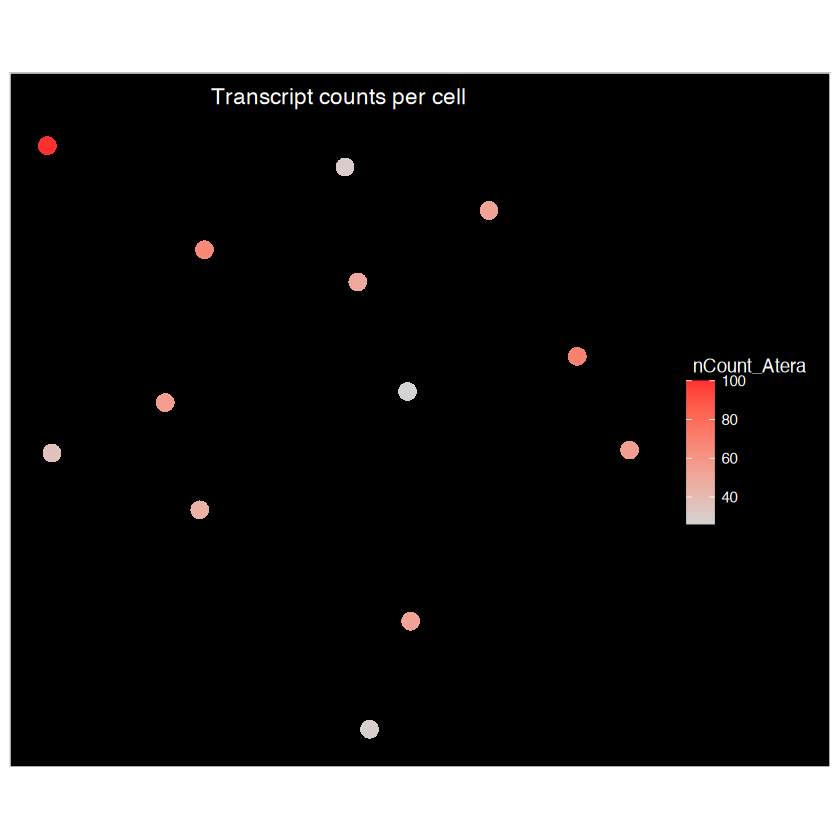

In [ ]:
ImageFeaturePlot(atera.obj,
  fov = "fov",
  features = "nCount_Atera",
  size = 5) + # for larger datasets use something smaller like 0.1
  ggplot2::ggtitle("Transcript counts per cell")


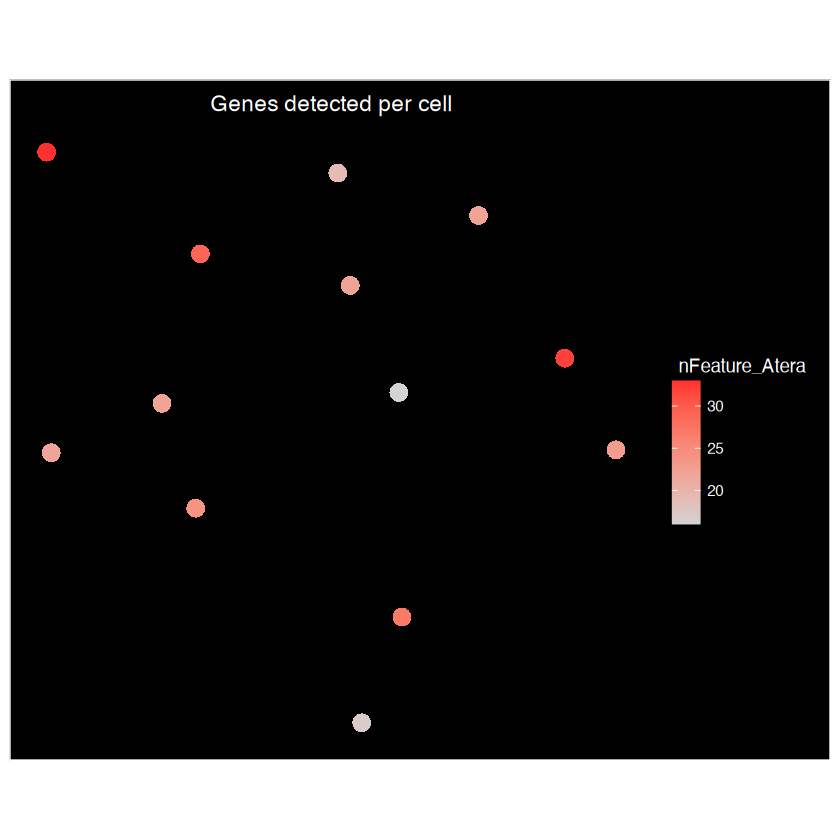

In [ ]:
ImageFeaturePlot(atera.obj,
  fov = "fov",
  features = "nFeature_Atera",
  size = 5) + # for larger datasets use something smaller like 0.1
ggplot2::ggtitle("Genes detected per cell")

## Plot transcripts spatial distribution for a single gene

Transcript coordinates are lazy (see `LoadAteraMolecules()`): only the gene(s) requested
here get fetched, not the whole transcript table. Adjust `gene_name` to one actually
present in your panel — check `rownames(atera.obj[["Atera"]])` if unsure.

Warning message:
“Overwriting miscellanous data for atera.molecules”


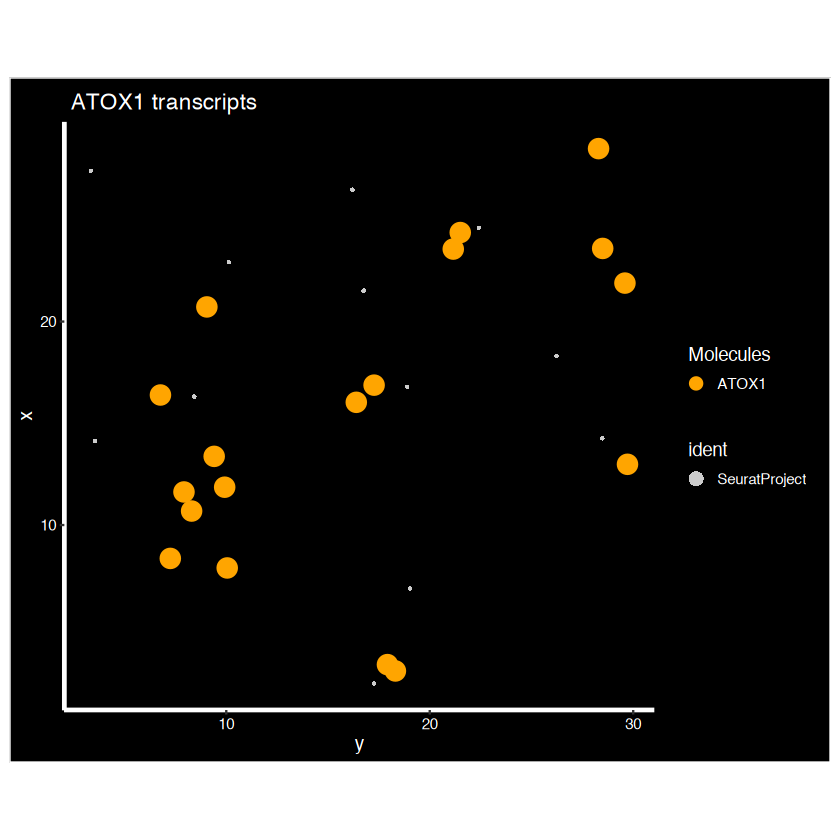

In [ ]:
gene_name <- "ATOX1"

atera.obj <- LoadAteraMolecules(atera.obj, genes = gene_name)

ImageDimPlot(
  atera.obj,
  fov = "fov",
  boundaries = NULL,  # centroids only -- no segmentation polygons loaded
  size = 1,  # for larger datasets use something smaller like 0.1
  cols = "grey80",
  molecules = gene_name,
  mols.size = 5,# for larger datasets use something smaller like 0.1
  mols.cols = "orange",
  axes = TRUE
) + ggplot2::ggtitle(paste(gene_name, "transcripts"))

## Plot transcripts for multiple genes

Set `genes` to two or more panel genes you want to compare spatially.

Warning message:
“Overwriting miscellanous data for atera.molecules”


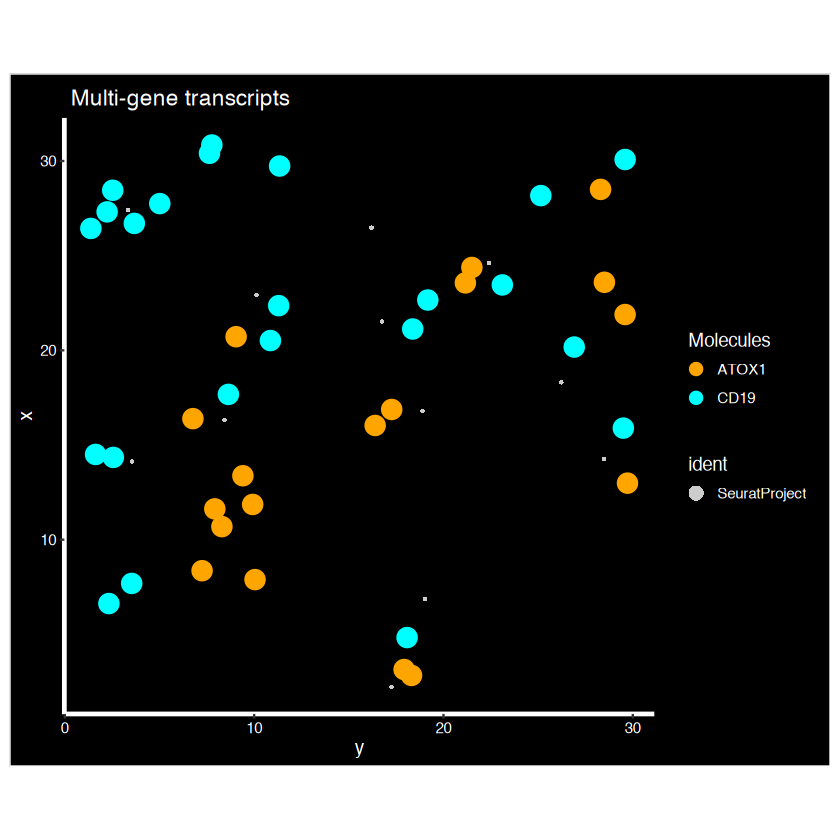

In [ ]:
genes <- c("ATOX1", "CD19")  # adjust to genes present in your panel

atera.obj <- LoadAteraMolecules(atera.obj, genes = genes)

ImageDimPlot(
  atera.obj,
  fov = "fov",
  boundaries = NULL,
  size = 1,# for larger datasets use something smaller like 0.1
  cols = "grey80",
  molecules = genes,
  mols.size = 5,# for larger datasets use something smaller like 0.1
  mols.cols = c("orange", "cyan"),
  axes = TRUE
) + ggplot2::ggtitle("Multi-gene transcripts")

## Plot codewords

Atera panels include "codeword" pseudo-features (negative controls, unassigned/
deprecated codewords, etc.) alongside real genes -- these show up in `rownames()`
with names like `UnassignedCodeword_<id>`/`DeprecatedCodeword_<id>` and can be fetched
the same way as any other gene via `LoadAteraMolecules()`. List a few to pick one that
actually exists in your panel:

Warning message:
“Overwriting miscellanous data for atera.molecules”


1 codewords for ATOX1 


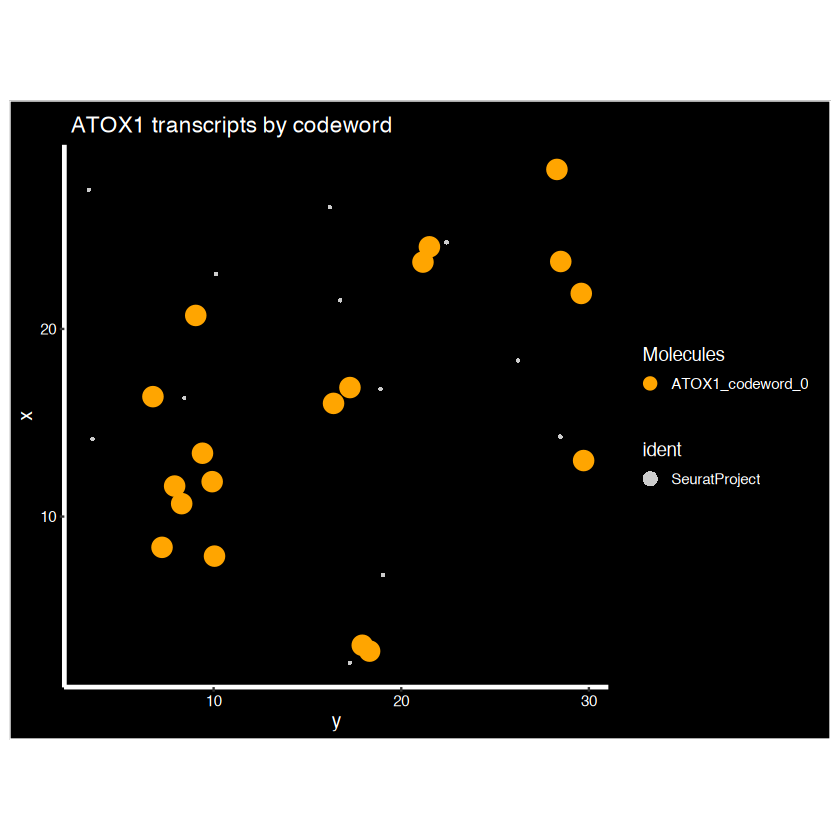

In [ ]:
gene_name <- "ATOX1"
atera.obj <- LoadAteraCodewords(atera.obj, data.dir = BUNDLE_PATH, genes = gene_name)

codeword.labels <- sort(unique(grep(
  paste0("^", gene_name, "_codeword_"),
  Misc(atera.obj, "atera.molecules")$cache$gene,
  value = TRUE
)))
cat(length(codeword.labels), "codewords for", gene_name, "\n")

palette <- c("orange", "cyan", "magenta", "yellow", "green", "red")  # extend if a gene has more codewords than this

ImageDimPlot(
  atera.obj,
  fov = "fov",
  boundaries = NULL,
  size = 1,# for larger datasets use something smaller like 0.1
  cols = "grey80",
  molecules = codeword.labels,
  mols.size = 5,# for larger datasets use something smaller like 0.1
  mols.cols = palette[seq_along(codeword.labels)],
  axes = TRUE
) + ggplot2::ggtitle(paste(gene_name, "transcripts by codeword"))

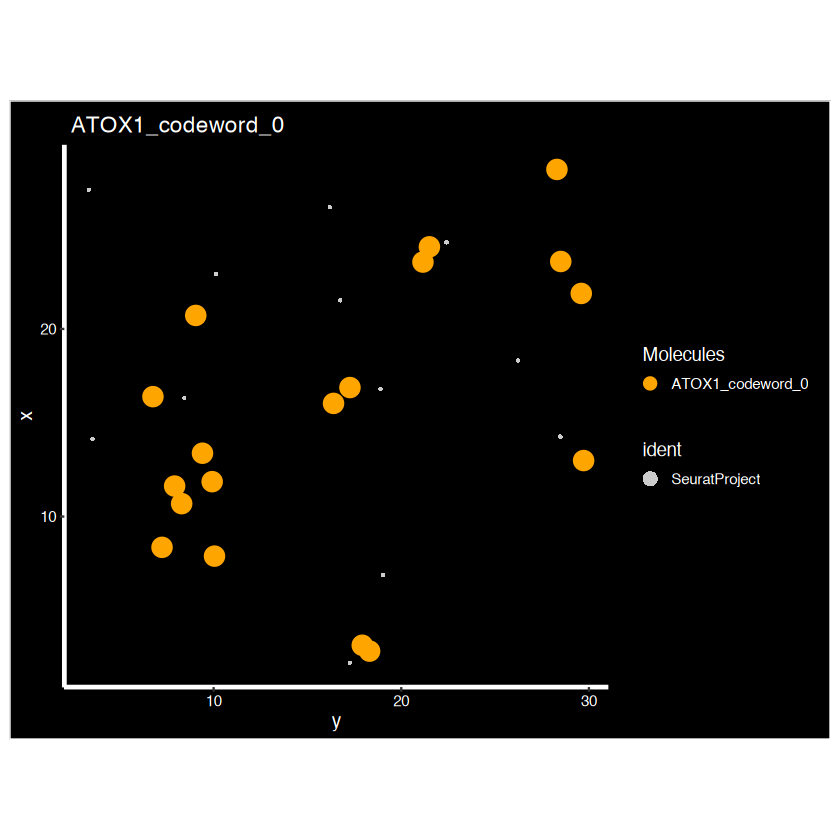

In [ ]:
plots <- lapply(codeword.labels, function(cw) {
  ImageDimPlot(
    atera.obj,
    fov = "fov",
    boundaries = NULL,
    size = 1,# for larger datasets use something smaller like 0.1
    cols = "grey80",
    molecules = cw,
    mols.size = 5,# for larger datasets use something smaller like 0.1
    mols.cols = "orange",
    axes = TRUE
  ) + ggplot2::ggtitle(cw)
})
combined <- patchwork::wrap_plots(plots, ncol = length(plots))
combined

### Crop to a specific region

This is the one place in this notebook that loads segmentation polygons and the
morphology image — both scoped to a small region, which is what keeps them fast (see
the intro). Adjust `x`/`y` to a region of interest in your bundle's tissue coordinates.

Warning message:
“Key ‘Atera_’ taken, using ‘fovcrop_’ instead”
Warning message:
“Overwriting miscellanous data for atera.molecules”


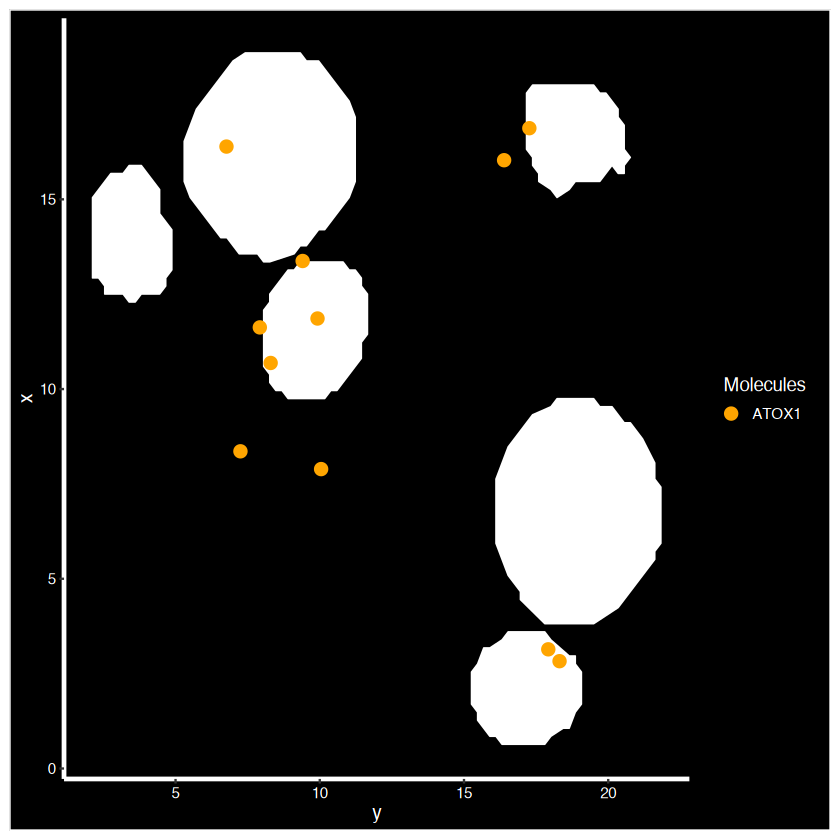

In [ ]:
atera.obj[["fov.crop"]] <- Crop(
  atera.obj[["fov"]],
  x = c(0, 20),
  y = c(0, 20),
  coords = "tissue"
)

# Cell segmentation polygons, built only for the ~hundreds-to-low-thousands of cells
# in this crop (see LoadAteraSegmentations()'s docs for why this doesn't scale to the
# whole bundle: sp::SpatialPolygons() overflows R's protection stack well before that).
atera.obj <- LoadAteraSegmentations(
  atera.obj,
  data.dir = BUNDLE_PATH,
  fov = "fov.crop",
  segmentations = "cell"
)

atera.obj <- LoadAteraMolecules(atera.obj, genes = "ATOX1")

ImageDimPlot(
  atera.obj,
  fov = "fov.crop",
  boundaries = "segmentations",
  cols = "white",
  axes = TRUE,
  molecules = "ATOX1",
  mols.size = 3, # for larger datasets use something smaller like 0.1
  mols.cols = "orange",
  coord.fixed = FALSE
)


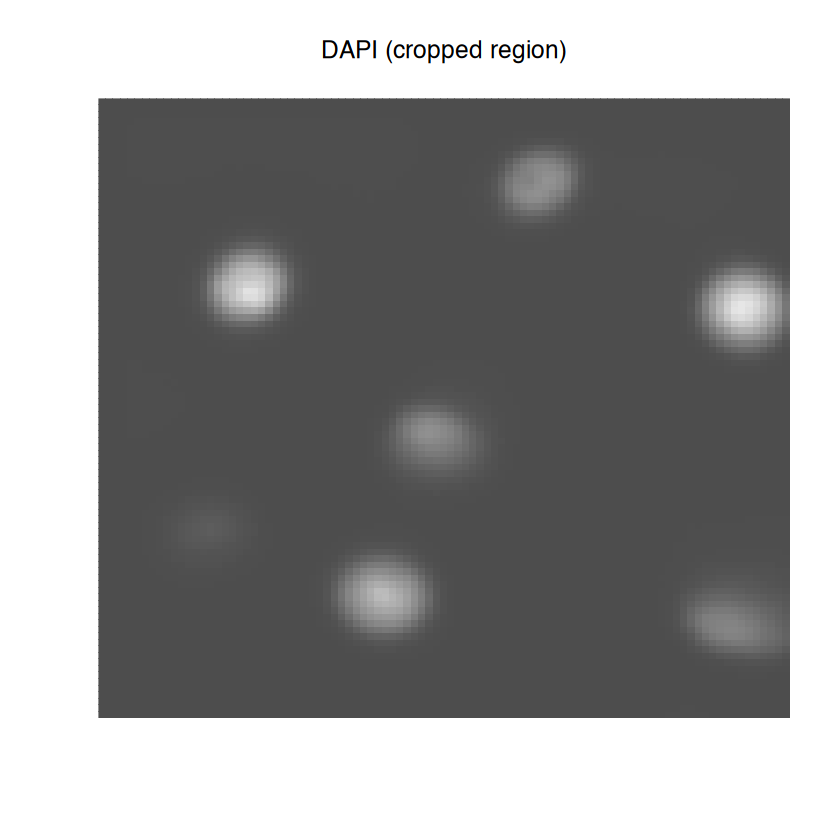

In [14]:
# DAPI morphology image, read directly for just this crop's region (micron
# coordinates) rather than via LoadAtera(morphology.image = TRUE), which would decode
# a whole-bundle plane eagerly on every call.
dapi.crop <- Seurat:::.AteraReadMorphologyImage(
  data.dir = BUNDLE_PATH,
  channel = "dapi",
  region = list(x = c(0, 20), y = c(0, 20))
)
image(
  t(dapi.crop$image)[, rev(seq_len(nrow(dapi.crop$image)))],
  col = grey.colors(256),
  axes = FALSE,
  main = "DAPI (cropped region)"
)

Warning message:
“Removing 7 cells missing data for vars requested”


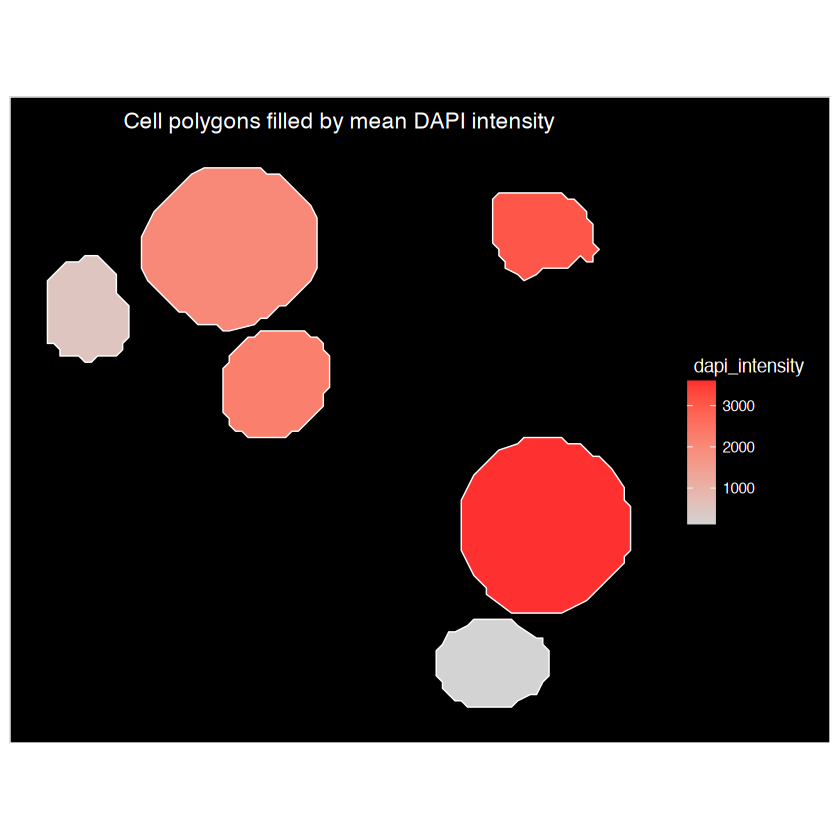

In [29]:
# Mean DAPI intensity per cell: for each cell's polygon, find which DAPI pixels fall
# inside it (point-in-polygon test, via sp -- already a Segmentation dependency) and
# average them. ImageFeaturePlot can then color/fill the polygons by this value the
# same way it does for nCount_Atera/nFeature_Atera earlier in this notebook.
px.x <- dapi.crop$origin["x"] + (seq_len(nrow(dapi.crop$image)) - 1) * dapi.crop$pixel.size
px.y <- dapi.crop$origin["y"] + (seq_len(ncol(dapi.crop$image)) - 1) * dapi.crop$pixel.size
grid <- expand.grid(x = px.x, y = px.y)
grid$value <- as.vector(dapi.crop$image)

seg <- atera.obj[["fov.crop"]][["segmentations"]]
dapi.means <- vapply(seg@polygons, function(p) {
  coords <- p@Polygons[[1]]@coords
  inside <- sp::point.in.polygon(grid$x, grid$y, coords[, 1], coords[, 2]) > 0
  mean(grid$value[inside], na.rm = TRUE)
}, numeric(1))
names(dapi.means) <- vapply(seg@polygons, function(p) p@ID, character(1))

atera.obj$dapi_intensity <- NA_real_
atera.obj$dapi_intensity[names(dapi.means)] <- dapi.means

ImageFeaturePlot(
  atera.obj,
  fov = "fov.crop",
  features = "dapi_intensity",
  boundaries = "segmentations",
  size = 0.3
) + ggplot2::ggtitle("Cell polygons filled by mean DAPI intensity")


## Normalization, PCA, UMAP, clustering (BPCells + sketching)

At whole-transcriptome, millions-of-cell scale, the "standard" pipeline run directly on
every cell doesn't hold up:

- `FindClusters()`'s Louvain/SLM step is dominated by local-moving convergence, which can
  take tens of minutes to hours at this scale.
- `RunPCA()` on a BPCells-backed matrix goes through `BPCells::svds()`, which scales with
  cell count regardless of how it's invoked.

Seurat5's sketch workflow instead: subsamples a small, statistically-representative
"sketch" of cells via leverage-score weighting (`SketchData`), runs the expensive
normalize/PCA/cluster/UMAP steps on just the sketch, then projects the results (PCA
embedding, UMAP, cluster labels) back onto the full dataset (`ProjectData`).
`LeverageScore` (called internally by `SketchData`) has a dedicated `IterableMatrix`
code path, so this works directly on `atera.obj` -- no extra adaptation needed.

In [ ]:
atera.obj <- NormalizeData(atera.obj)
atera.obj <- FindVariableFeatures(atera.obj)
atera.obj <- SketchData(
  object = atera.obj,
  assay = "Atera",
  ncells = 50, # for larger sample update to 50-100k
  sketched.assay = "sketch"
)
# SketchData() sets DefaultAssay to "sketch" -- the steps below all run on just the
# sketched cells, not the full dataset.

Normalizing layer: counts

Finding variable features for layer counts

Warning message:
“pseudoinverse used at -0.034762”
Warning message:
“neighborhood radius 0.034762”
Warning message:
“reciprocal condition number  0”
Warning message:
“There are other near singularities as well. 0.0010359”
Calcuating Leverage Score

Running LeverageScore for layer data

No variable features were found in data. Falling back to variable features from counts

Warning message in irlba(A = object, nv = nv, nu = 0, verbose = FALSE):
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message in irlba(A = object, nv = nv, nu = 0, verbose = FALSE):
“did not converge--results might be invalid!; try increasing work or maxit”
Attempting to cast layer counts to dgCMatrix

Attempting to cast layer data to dgCMatrix



In [17]:
atera.obj <- NormalizeData(atera.obj)
atera.obj <- FindVariableFeatures(atera.obj)
atera.obj <- ScaleData(atera.obj, features = VariableFeatures(atera.obj))

Normalizing layer: counts



Computing: [========================================] 100% (done)                         


Finding variable features for layer counts

Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.034762”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.034762”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 0.0010359”


Computing: [========================================] 100% (done)                         


Centering and scaling data matrix



Computing: [========================================] 100% (done)                         


In [18]:
atera.obj <- RunPCA(atera.obj, features = VariableFeatures(atera.obj), npcs = 30)

Warning message:
“Requested number is larger than the number of available items (53). Setting to 53.”
Warning message:
“Requested number is larger than the number of available items (53). Setting to 53.”
Warning message:
“Requested number is larger than the number of available items (53). Setting to 53.”
Warning message:
“Requested number is larger than the number of available items (53). Setting to 53.”
Warning message:
“Requested number is larger than the number of available items (53). Setting to 53.”
PC_ 1 
Positive:  CD86, CD4, KLRC1, TOX2, CD3G, CD37, GZMB, TIGIT, CD3D, STOX2 
	   CD40, ATOX1, GZMK, CD300LG, TCF7, TOX3, PLCD4, CD38, TRBC2, KLRB1 
	   FOXP3, TOX, TRAC, NKG7, TCF7L2, CD300E 
Negative:  CD48, KLRD1, CD44, CD79A, KLRF1, PRF1, PAX5, CD8A, CD36, TINCR 
	   GNLY, CD79B, C2CD4B, MS4A1, TRBC1, CD83, LEF1, CD320, CD3E, KLRC2 
	   CD34, CD47, CD81, LAG3, PDCD4, CD19 
PC_ 2 
Positive:  CD300E, CD81, PDCD4, TOX3, LEF1, GZMK, CD38, PLCD4, PRF1, CD47 
	   CD3E, KLRB1, CD8B, KLR

Warning message:
“k.param set larger than number of cells. Setting k.param to number of cells - 1.”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 13
Number of edges: 78

Running smart local moving algorithm...
Computing: [========================================] 100% (done)                         
Maximum modularity in 8 random starts: -0.0000
Number of communities: 1
Elapsed time: 0 seconds


UMAP will return its model

14:53:43 UMAP embedding parameters a = 0.9922 b = 1.112

14:53:43 Read 13 rows and found 5 numeric columns

14:53:43 Using Annoy for neighbor search, n_neighbors = 5

14:53:43 Building Annoy index with metric = cosine, n_trees = 50

14:53:43 Writing NN index file to temp file /var/folders/gy/zwg8cq_n6ms33c3v1mqq8_8c0000gp/T//RtmpXoVfOK/file9e816f22b0c8

14:53:43 Searching Annoy index using 8 threads, search_k = 500

14:53:43 Annoy recall = 100%

14:53:43 Commencing smooth kNN distance calibration using 8 threads
 with target n_neighbors = 5

14:53:43 Found 2 connected components, 
falling back to 'spca' initialization with init_sdev = 1

14:53:43 Using 'irlba' for PCA

14:53:43 PCA: 2 components explained 78.85% variance

14:53:43 Scaling init to sdev = 1

14:53:43 Commencing optimization for 500 epochs, with 64 positive edges

14:53:43 Using rng type: pcg

14:53:44 Optimization finished



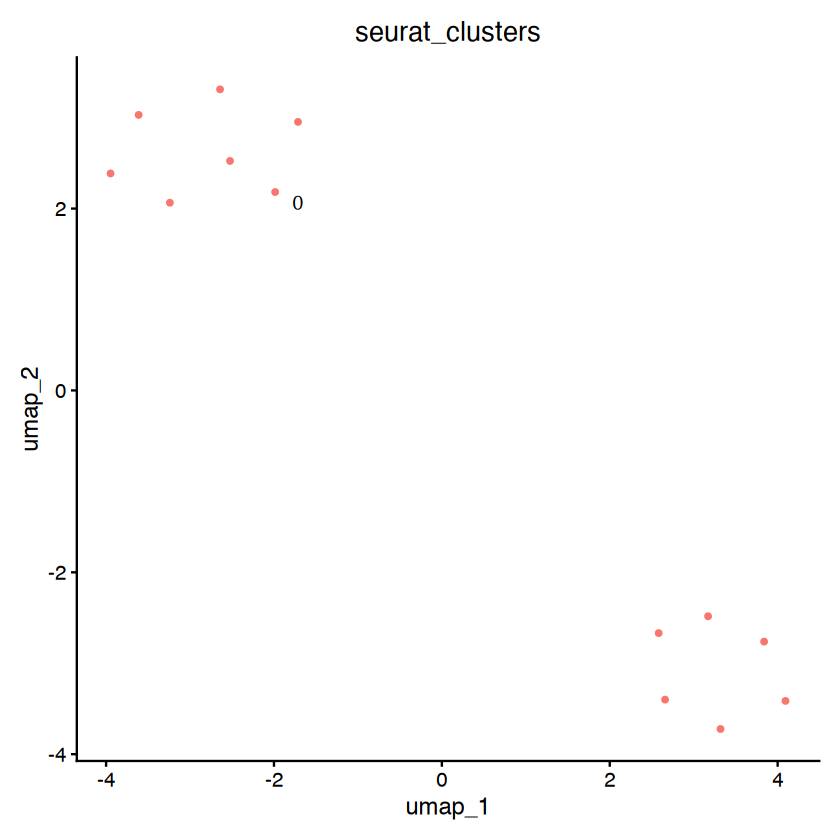

In [ ]:
atera.obj <- FindNeighbors(atera.obj, dims = 1:5) # update this for larger datasets (e.g. 1:30) and remove n.neighbors
# algorithm = 3 (SLM) scales better than the default Louvain at this cell count;
# n.start matches setThreads() above so the n.start random restarts split evenly
# across threads (see FindNeighbors/FindClusters threading notes).
atera.obj <- FindClusters(atera.obj, resolution = 1.0, algorithm = 3, n.start = 8)
# return.model = TRUE is required for ProjectData() to be able to project the full
# dataset into this sketch's UMAP space below.
atera.obj <- RunUMAP(atera.obj, dims = 1:5, return.model = TRUE, n.neighbors = 5) # update this for larger datasets (e.g. 1:30) and remove n.neighbors
DimPlot(atera.obj, group.by = "seurat_clusters", label = TRUE) + NoLegend()

## Project sketch results back onto the full dataset

`full.reduction`/`umap.model` together determine the output reduction names:
`"pca.full"` (PCA embedding for every cell) and `"full.umap"` (UMAP embedding for every
cell, derived from `umap.model`'s name) — the latter only gets created if `RunUMAP()`
above was called with `return.model = TRUE`.

In [ ]:
atera.obj <- ProjectData(
  object = atera.obj,
  assay = "Atera",
  sketched.assay = "sketch",
  sketched.reduction = "pca",
  full.reduction = "pca.full",
  dims = 1:5, # update this for larger datasets (e.g. 1:30) 
  k.weight = 5, # remove this for non-tiny sample
  umap.model = "umap",
  refdata = list(cluster_full = "seurat_clusters")
)
DefaultAssay(atera.obj) <- "Atera"


pca.full is not in the object. Data from all cells will be projected to pca

Projecting cell embeddings

Finding sketch neighbors

Finding sketch weight matrix

Transfering refdata from sketch

All grouping variables have 1 value only. Computing across all cells.

Projection to sketch umap

Running UMAP projection

14:55:01 Read 13 rows

14:55:01 Processing block 1 of 1

14:55:01 Commencing smooth kNN distance calibration using 8 threads
 with target n_neighbors = 5

14:55:01 Initializing by weighted average of neighbor coordinates using 8 threads

14:55:01 Commencing optimization for 167 epochs, with 65 positive edges

14:55:01 Finished

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from full.umap to fullumap_”


## Plot the clusters

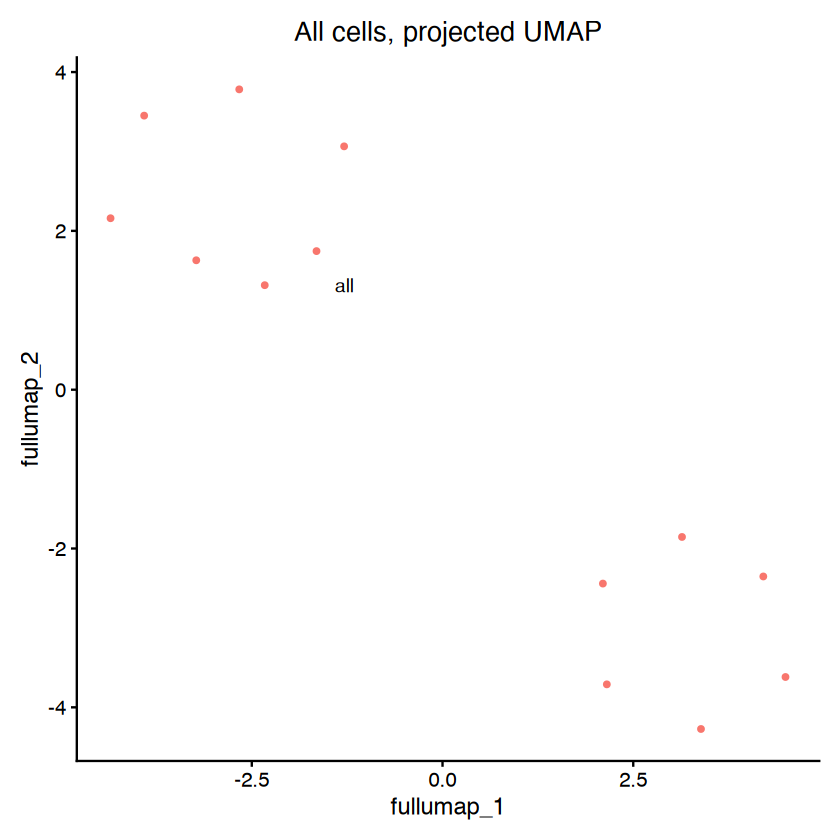

In [24]:
DimPlot(atera.obj, reduction = "full.umap", group.by = "cluster_full", label = TRUE) +
  NoLegend() + ggplot2::ggtitle("All cells, projected UMAP")

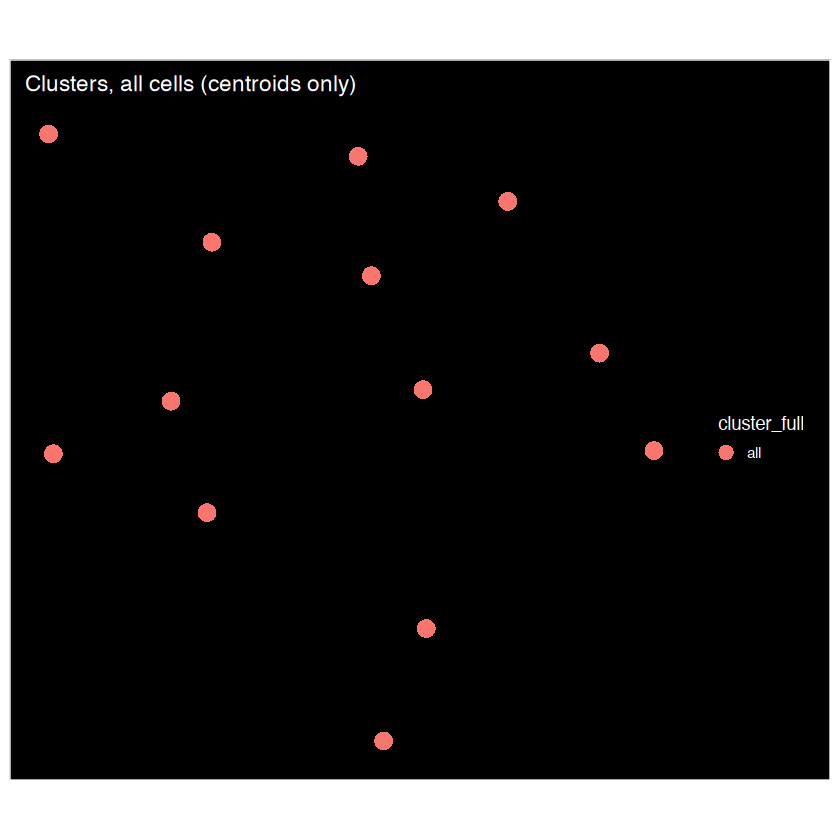

In [26]:
# Whole-bundle overview: centroids only, no segmentation polygons (see intro).
ImageDimPlot(atera.obj, fov = "fov", group.by = "cluster_full", size = 5) +
  ggplot2::ggtitle("Clusters, all cells (centroids only)")

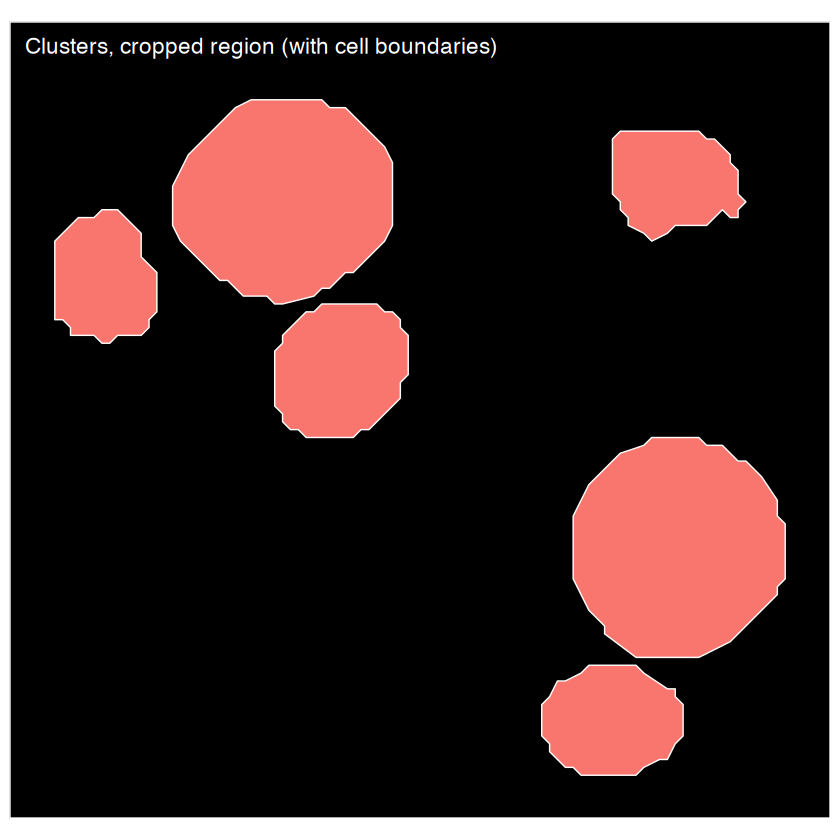

In [27]:
# Cropped-region view reusing the segmentation polygons loaded earlier: real cell
# boundaries, not just points, since this FOV is small enough for it to be fast.
ImageDimPlot(
  atera.obj,
  fov = "fov.crop",
  group.by = "cluster_full",
  boundaries = "segmentations",
  size = 5
) + ggplot2::ggtitle("Clusters, cropped region (with cell boundaries)")
